# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [22]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [24]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# svm_grid_search = ...
# svm_grid_search.fit(...)
svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [25]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
cv_results_df = pd.DataFrame(svm_grid_search.cv_results_)
cv_results_top10 = (cv_results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
                     .sort_values('rank_test_score').head(10))
print(cv_results_top10.to_string(index=False))

                                                         params  mean_test_score  std_test_score  rank_test_score
       {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}         0.978633        0.017581                1
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}         0.976215        0.015266                2
  {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}         0.976215        0.015266                2
   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}         0.976215        0.015266                2
     {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.976157        0.016975                5
      {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.971340        0.016281                6
     {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969357        0.019323                7
    {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969350        

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
        'n_estimators': randint(50, 500),
    'max_depth': [None] + list(range(2, 20)),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 19, 'max_features': 0.5, 'min_samples_split': 4, 'n_estimators': 356}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [27]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_baseline = base_models['SVM']
svm_baseline.fit(X_train, y_train)
y_pred_svm_base = svm_baseline.predict(X_test)

rf_baseline = base_models['RandomForest']
rf_baseline.fit(X_train, y_train)
y_pred_rf_base = rf_baseline.predict(X_test)

best_svm = svm_grid_search.best_estimator_
y_pred_svm_grid = best_svm.predict(X_test)

best_rf = rf_random_search.best_estimator_
y_pred_rf_random = best_rf.predict(X_test)

print("--- SVM baseline ---")
print(classification_report(y_test, y_pred_svm_base))
print("--- SVM Grid Search (best) ---")
print(classification_report(y_test, y_pred_svm_grid))
print("--- RF baseline ---")
print(classification_report(y_test, y_pred_rf_base))
print("--- RF Random Search (best) ---")
print(classification_report(y_test, y_pred_rf_random))
# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

--- SVM baseline ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- SVM Grid Search (best) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- RF baseline ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
we

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

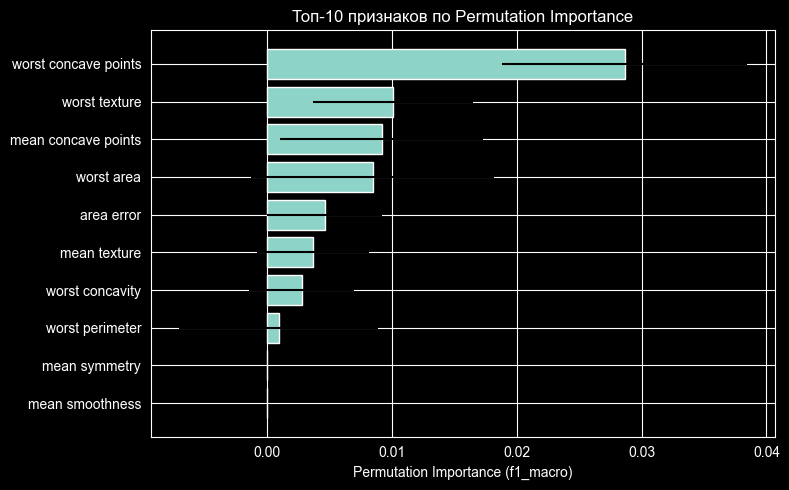

In [28]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# pi_result = permutation_importance(...)
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10,
                                    random_state=42, scoring='f1_macro')

pi_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': pi_result.importances_mean,
    'importance_std': pi_result.importances_std,
}).sort_values('importance_mean', ascending=False)

top10_pi = pi_df.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top10_pi['feature'][::-1], top10_pi['importance_mean'][::-1],
         xerr=top10_pi['importance_std'][::-1])
plt.xlabel('Permutation Importance (f1_macro)')
plt.title('Топ-10 признаков по Permutation Importance')
plt.tight_layout()
plt.show()

# Построим bar plot топ-10 признаков
# YOUR CODE HERE

In [29]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
fi_df = pd.DataFrame({
    'feature': feature_names,
    'feature_importance': best_rf.feature_importances_,
}).sort_values('feature_importance', ascending=False)

print("Топ-5 по PI:", pi_df['feature'].head(5).tolist())
print("Топ-5 по feature_importances_:", fi_df['feature'].head(5).tolist())
# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

Топ-5 по PI: ['worst concave points', 'worst texture', 'mean concave points', 'worst area', 'area error']
Топ-5 по feature_importances_: ['worst perimeter', 'worst concave points', 'worst area', 'worst radius', 'mean concave points']


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

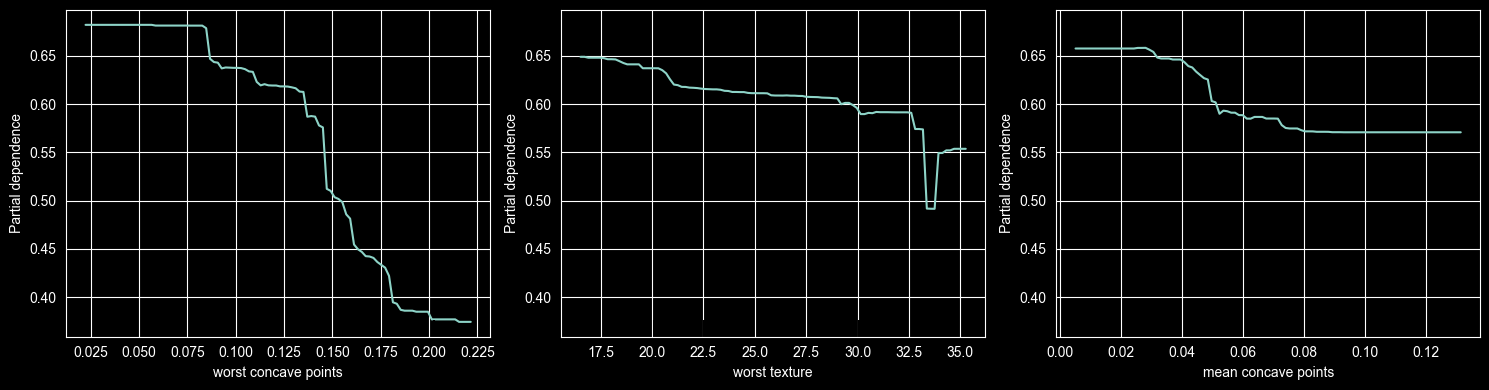

In [40]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_features = pi_df['feature'].head(3).tolist()
top3_idx = [list(feature_names).index(f) for f in top3_features]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(best_rf, X_test, features=top3_idx,
                                         feature_names=feature_names,
                                         kind='average', ax=ax)
plt.tight_layout()
plt.show() # YOUR CODE HERE

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
plt.tight_layout()
plt.show()

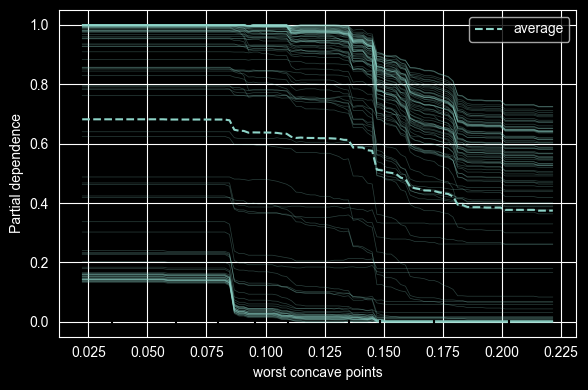

In [31]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝
most_important = top3_idx[0]
fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(best_rf, X_test, features=[most_important],
                                         feature_names=feature_names,
                                         kind='both', ax=ax)
plt.tight_layout()
plt.show()
# YOUR CODE HERE

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [32]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# explainer = ...
# shap_values = ...
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print("shap_values shape:", np.array(shap_values).shape)

shap_values shape: (114, 30, 2)


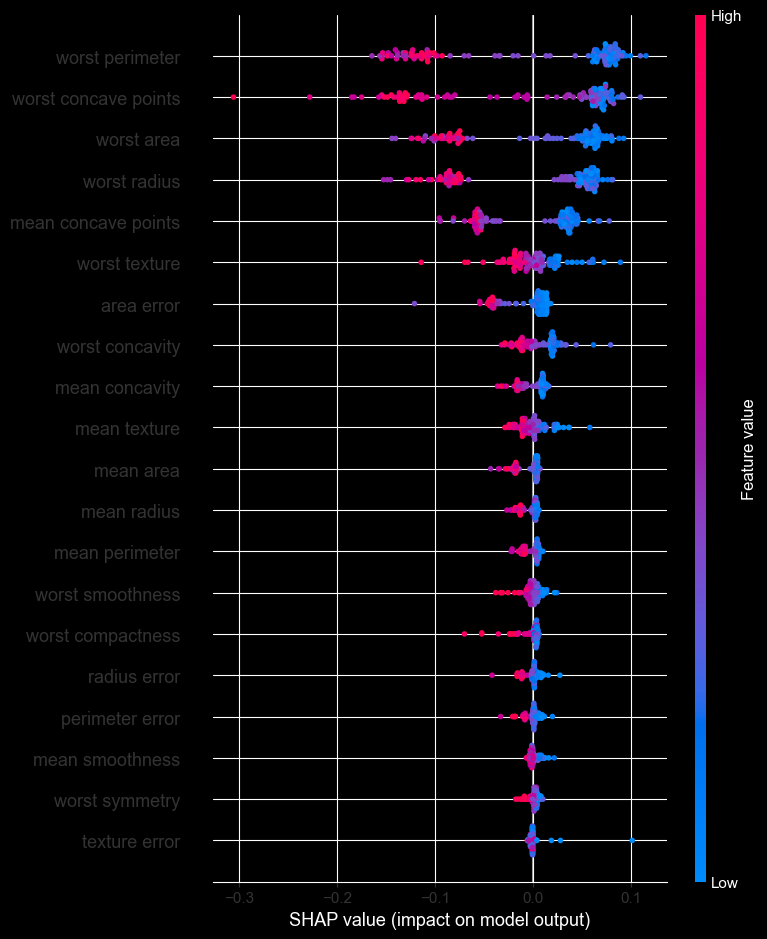

Топ-5 по SHAP: ['worst perimeter', 'worst concave points', 'worst area', 'worst radius', 'mean concave points']


In [33]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# Универсально работает и со старым (list), и с новым (3D array) форматом shap
if isinstance(shap_values, list):
    sv_class1 = shap_values[1]
else:
    sv_arr = np.array(shap_values)
    sv_class1 = sv_arr[:, :, 1] if sv_arr.ndim == 3 else sv_arr

shap.summary_plot(sv_class1, X_test, feature_names=feature_names)

shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(sv_class1).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print("Топ-5 по SHAP:", shap_importance['feature'].head(5).tolist())

In [34]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
# shap.force_plot(...)
y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

idx = errors[0]
if isinstance(explainer.expected_value, (list, np.ndarray)):
    ev = explainer.expected_value[1]
else:
    ev = explainer.expected_value

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0
Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [35]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

In [36]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(random_state=42)
rf_ext.fit(X_train_ext, y_train)
y_pred_ext = rf_ext.predict(X_test_ext)

print("F1 без подозрительных признаков:",
      f"{f1_score(y_test, best_rf.predict(X_test), average='macro'):.4f}")
print("F1 с leaky_feature и random_feature:",
      f"{f1_score(y_test, y_pred_ext, average='macro'):.4f}")

feature_names_ext = X_train_ext.columns

pi_ext = permutation_importance(rf_ext, X_test_ext, y_test, n_repeats=10,
                                 random_state=42, scoring='f1_macro')
pi_ext_df = pd.DataFrame({
    'feature': feature_names_ext,
    'importance_mean': pi_ext.importances_mean
}).sort_values('importance_mean', ascending=False)
print(pi_ext_df.head(5).to_string(index=False))

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = np.array(explainer_ext.shap_values(X_test_ext))
sv_ext_class1 = shap_values_ext[:, :, 1] if shap_values_ext.ndim == 3 else shap_values_ext

shap_imp_ext = pd.DataFrame({
    'feature': feature_names_ext,
    'mean_abs_shap': np.abs(sv_ext_class1).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print(shap_imp_ext.head(5).to_string(index=False))

F1 без подозрительных признаков: 0.9526
F1 с leaky_feature и random_feature: 1.0000
             feature  importance_mean
       leaky_feature         0.263342
 mean concave points         0.004689
worst concave points         0.003752
         mean radius         0.000000
           mean area         0.000000
             feature  mean_abs_shap
       leaky_feature       0.158200
          worst area       0.052164
 mean concave points       0.038178
worst concave points       0.035742
        worst radius       0.033965


## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [37]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# SVM baseline 0.9694 0.9812 Хороший бейзлайн, тюнинг почти не дал прироста
# SVM Grid Search 0.9786 0.9812 CV F1 выше, Test F1 не изменился — модель уже близка к потолку
# RF baseline 0.9504 0.9526 Слабее SVM, чувствителен к глубине/числу деревьев
# RF Rand Search 0.9554 0.9526 CV улучшился, Test остался прежним

1. Незначительно: SVM Grid Search улучшил CV F1 с 0.969 до 0.979, но Test F1 не изменился (0.9812 в обоих случаях) — модель уже была близка к потолку на дефолтных параметрах. RF после Random Search улучшил CV (0.950 -> 0.955), но Test F1 тоже не изменился (0.9526). На этом датасете тюнинг даёт небольшой выигрыш, так как задача относительно простая и хорошо разделима.


2.  Частично. Топ-5 по SHAP почти совпадает с топ-5 по feature_importances_ (4 из 5), но с топ-5 по PI пересекаются только 2 признака (worst concave points, mean concave points). Причина — SHAP и feature_importances_ основаны на структуре дерева (вклад в снижение impurity/предсказание), а PI — на падении метрики на test при перемешивании, что иначе работает для коррелированных признаков (perimeter/radius/area сильно коррелируют между собой, и PI "распределяет" их важность по-другому, чем структурные метрики).


3.  Для SVM и LogisticRegression пришлось бы вручную вызывать scaler.fit_transform(X_train) / scaler.transform(X_test) отдельно от модели — высокий риск утечки данных (например, если fit сделать на всей выборке до разбиения, или забыть применить transform к test тем же scaler'ом). Pipeline гарантирует, что StandardScaler обучается только на train-фолде при CV/GridSearch и применяется к test без утечки, а также упрощает подбор гиперпараметров через 'svm__C'-нотацию.


4.  PI — для быстрой проверки на этапе валидации: какие признаки реально нужны модели (можно убрать признаки с PI≈0 для упрощения пайплайна и ускорения инференса), а также для обнаружения утечек (резко доминирующий признак — подозрение на leakage, как в шаге 9). SHAP — для глобальной интерпретации (summary plot — объяснить модель стейкхолдерам/регулятору) и для локальных объяснений конкретных решений (force plot — почему модель ошиблась на конкретном объекте или почему конкретному клиенту отказали), что важно для отчётности и доверия к модели.

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [38]:
# !pip install optuna

#import optuna
#optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")